# Marketing Campaign Response — MLP with PCA

A neural-network classification experiment combining scaling, dimensionality reduction, Optuna tuning and threshold evaluation.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**CONSTANTS**


In [1]:
FILE_NAME = 'data/campaign_clean.csv'


**IMPORTS**


In [4]:
import pandas as pd
from copy import deepcopy
import numpy as np
from IPython.display import display, HTML
import holoviews as hv
import seaborn as sns
import hvplot.pandas
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    make_scorer, 
    precision_score, 
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)

import optuna
from optuna.integration import OptunaSearchCV


**OPTIONS**


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
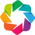

In [7]:
hv.extension('bokeh')


# 1. Data Preprocessing


In [9]:
df_model = pd.read_csv('../data/campaign_clean.csv')
df_model.head()


,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Month,Customer_Year
0,0,5524,1957,Graduation,Single,58138,0,0,2012-09-04,58,635.0,88.0,546,172,88,88.0,3,8,10,4,7,False,False,False,False,False,False,3,11,True,9,2012
1,1,2174,1954,Graduation,Single,46344,1,1,2014-03-08,38,11.0,1.0,6,2,1,6.0,2,1,1,2,5,False,False,False,False,False,False,3,11,False,3,2014
2,2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426.0,49.0,127,111,21,42.0,1,8,2,10,4,False,False,False,False,False,False,3,11,False,8,2013
3,3,6182,1984,Graduation,Together,26646,1,0,2014-02-10,26,11.0,4.0,20,10,3,5.0,2,2,0,4,6,False,False,False,False,False,False,3,11,False,2,2014
4,4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173.0,43.0,118,46,27,15.0,5,5,3,6,5,False,False,False,False,False,False,3,11,False,1,2014


In [10]:
#Drop rows where `Marital_Status` is `YOLO` or `Absurd`
df_model = df_model.loc[~df_model['Marital_Status'].isin(['YOLO', 'Absurd'])]

#Reassign Alone to Single
df_model.loc[df_model['Marital_Status']=='Alone', 'Marital_Status'] = 'Single'

#Drop Alone
if isinstance(df_model['Marital_Status'].dtype, pd.CategoricalDtype):
    df_model['Marital_Status'] = (
        df_model['Marital_Status']
            .cat.remove_unusused_categories()
    )

df_model['Marital_Status'].value_counts()


Marital_Status
Married     836
Together    560
Single      457
Divorced    228
Widow        73
Name: count, dtype: int64

### Feature Engineering


In [12]:
#Aggregate data by customer for RFM analysis (Recency, Frequency, Monetary Value)
# Compute Frequency 
df_model['Frequency'] = (
    df_model[['NumDealsPurchases',
             'NumWebPurchases',
             'NumCatalogPurchases',
             'NumStorePurchases']]
    .sum(axis=1)
)

# Compute Monetary
df_model['Monetary'] = (
    df_model[['MntWines',
             'MntFruits',
             'MntMeatProducts',
             'MntFishProducts',
             'MntSweetProducts',
             'MntGoldProds']]
    .sum(axis=1)
)

#Bucket into quartiles
df_model['R_Score'] = pd.qcut(df_model['Recency'], 4, labels=[4,3,2,1])  #in the case of recency, lower is better than higher, unlike the others
df_model['F_Score'] = pd.qcut(df_model['Frequency'], 4, labels=[1,2,3,4])
df_model['M_Score'] = pd.qcut(df_model['Monetary'], 4, labels=[1,2,3,4])


In [13]:
bool_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Complain"
]
df_model[bool_cols] = df_model[bool_cols].astype(int)


In [14]:
df_model.loc[df_model.Response == True].sample(4)


,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Month,Customer_Year,Frequency,Monetary,R_Score,F_Score,M_Score
1752,1827,5302,1986,Graduation,Together,78394,0,0,2013-02-15,13,298.0,27.0,697,216,24,166.0,1,4,6,5,2,0,0,0,0,0,0,3,11,True,2,2013,16,1428.0,4,3,4
782,820,9493,1980,PhD,Single,76412,0,0,2013-05-05,15,840.0,53.0,804,23,71,17.0,1,5,4,8,3,0,0,1,1,0,0,3,11,True,5,2013,18,1808.0,4,3,4
102,111,7431,1991,PhD,Single,68126,0,0,2012-11-10,40,1332.0,17.0,311,23,51,86.0,1,7,4,5,9,0,1,0,0,0,0,3,11,True,11,2012,17,1820.0,3,3,4
1539,1614,6215,1977,Graduation,Married,31353,1,1,2013-12-29,24,10.0,0.0,10,3,1,7.0,2,1,1,2,8,0,0,0,0,0,0,3,11,True,12,2013,6,31.0,4,1,1


In [15]:
num_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df_model.select_dtypes(include=['object','category']).columns.tolist()


In [16]:
print(f'numeric columns: {num_cols}')
print(f'categorical columns: {cat_cols}')
print(f'boolean columns: {bool_cols}')


numeric columns: ['Unnamed: 0', 'ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Customer_Month', 'Customer_Year', 'Frequency', 'Monetary']
categorical columns: ['Education', 'Marital_Status', 'Dt_Customer', 'R_Score', 'F_Score', 'M_Score']
boolean columns: ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']


Keeping all the variables can have pros and cons.  
**Pros of keeping all the variables:**
* keeps granularity, more information for the model  

**Cons of keeping all the columns:**
* high collinearity of the variables might hurt models that are more sensitive. MLP might need stronger regularisation.


In [18]:
money_cols = ['Monetary',
              'Income',
              'MntWines',
              'MntFruits',
              'MntMeatProducts',
              'MntFishProducts',
              'MntSweetProducts',
              'MntGoldProds']

count_cols  = ['Frequency',
               'NumDealsPurchases',
               'NumStorePurchases',
               'NumCatalogPurchases',
               'NumWebPurchases',
               'NumWebVisitsMonth']

# remove variables from num_cols so that they aren't duplicated
for c in money_cols + count_cols + bool_cols:
    if c in num_cols:
        num_cols.remove(c)



=== MONEY (8 vars) ===


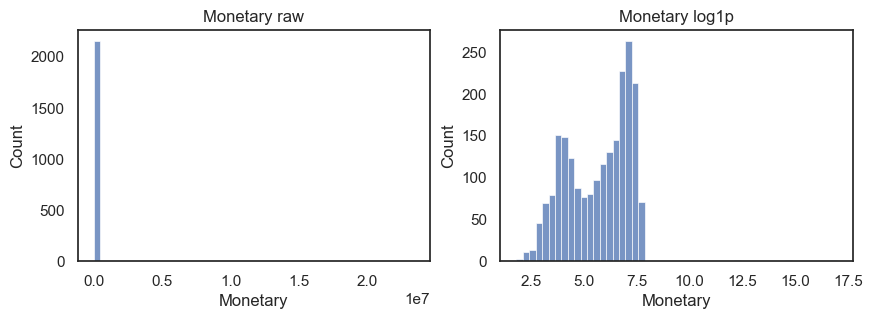

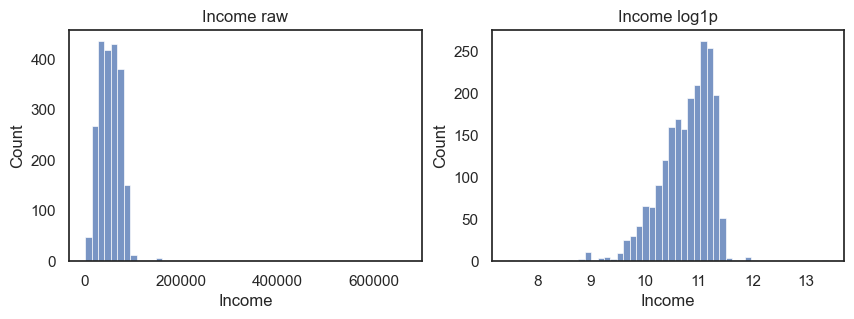

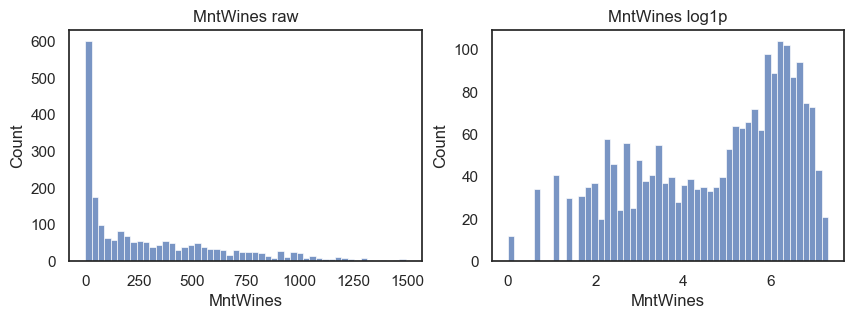

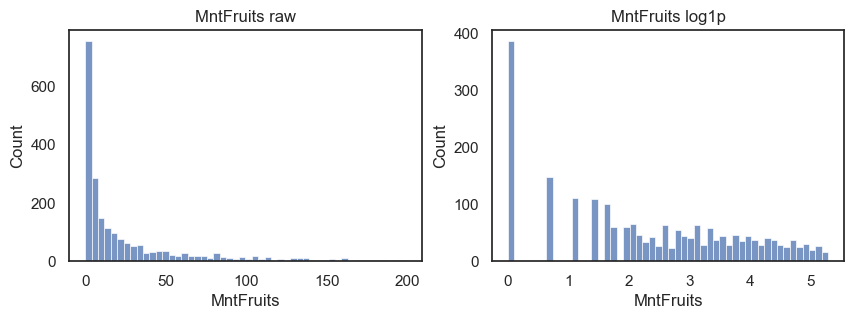

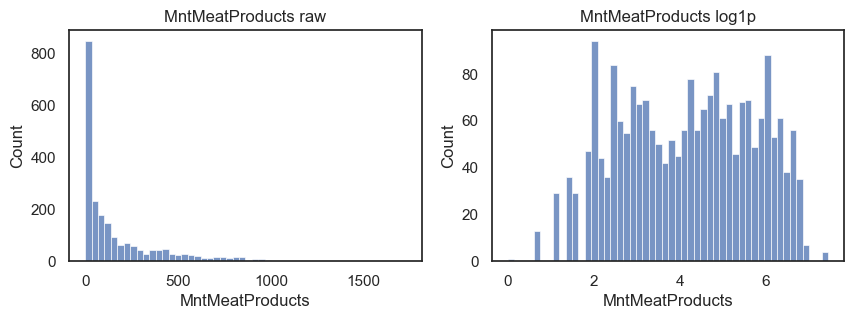

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


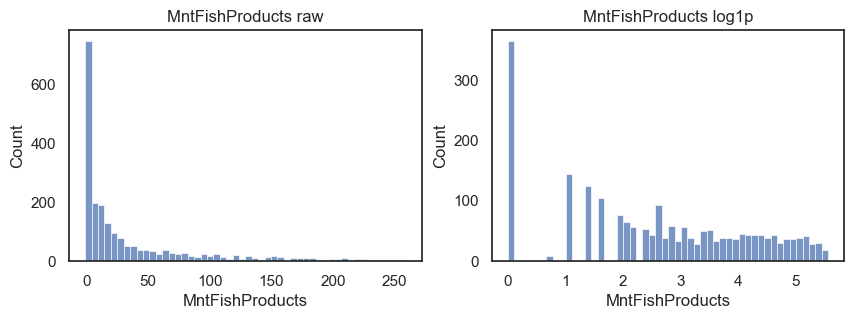

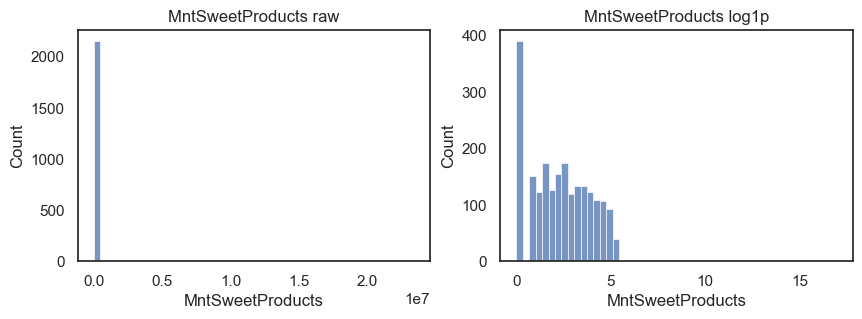

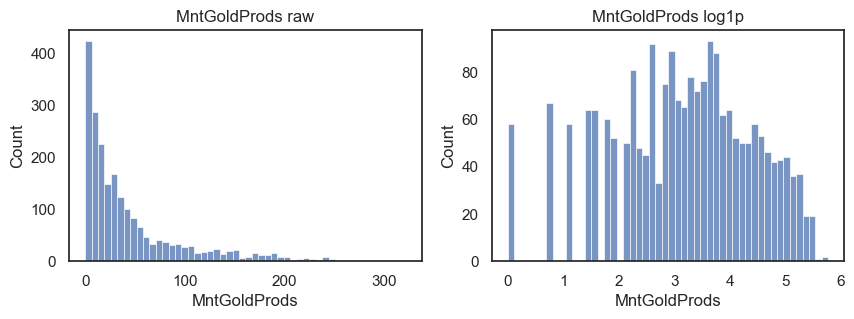

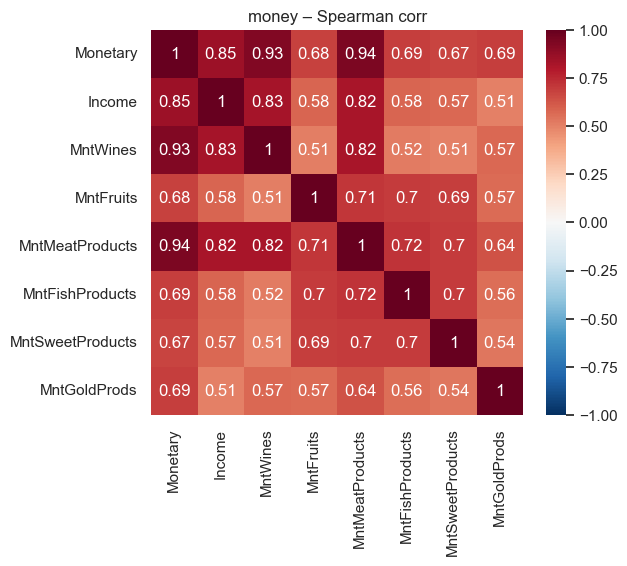


=== COUNT (6 vars) ===


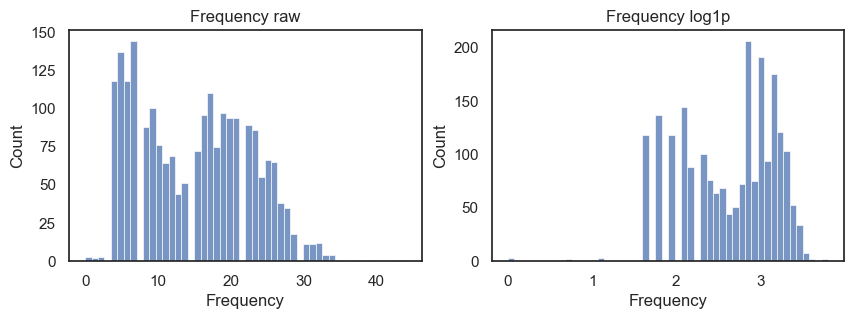

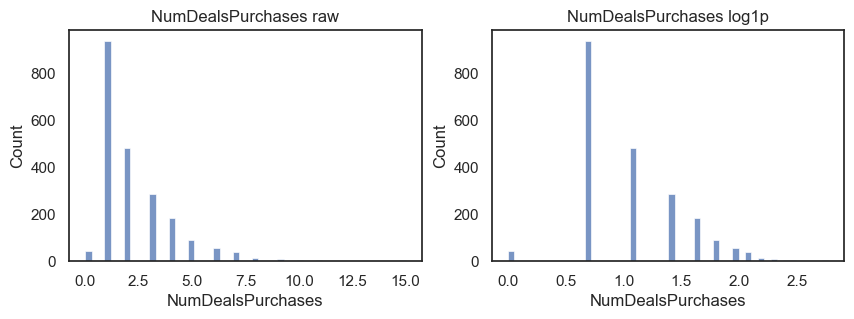

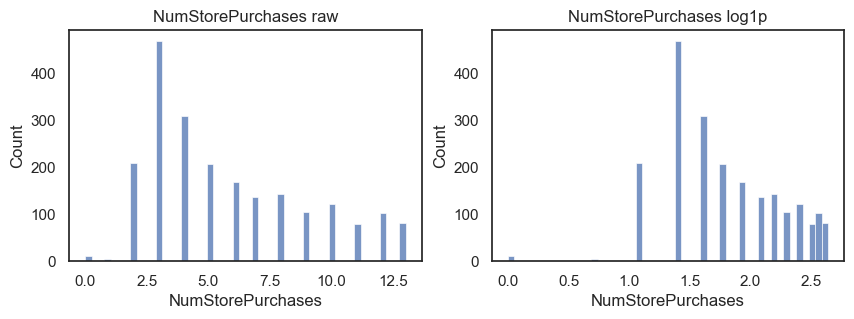

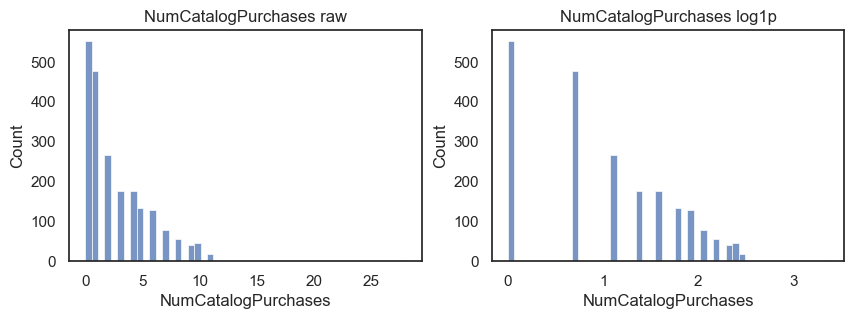

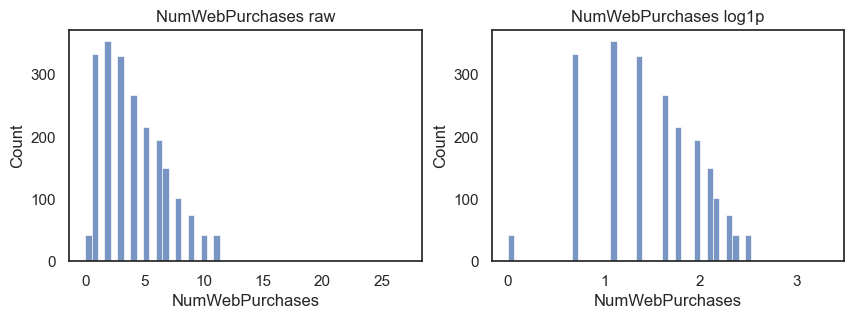

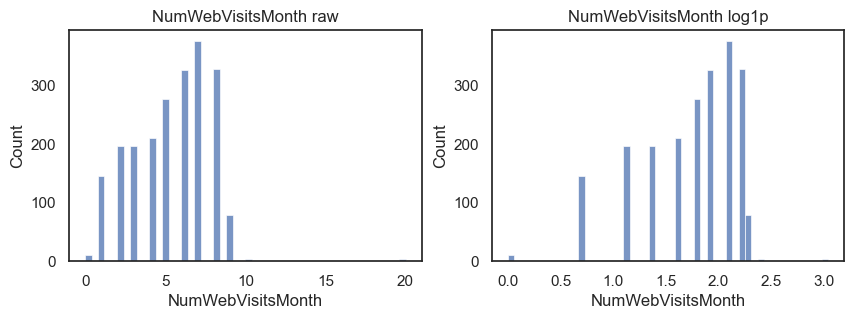

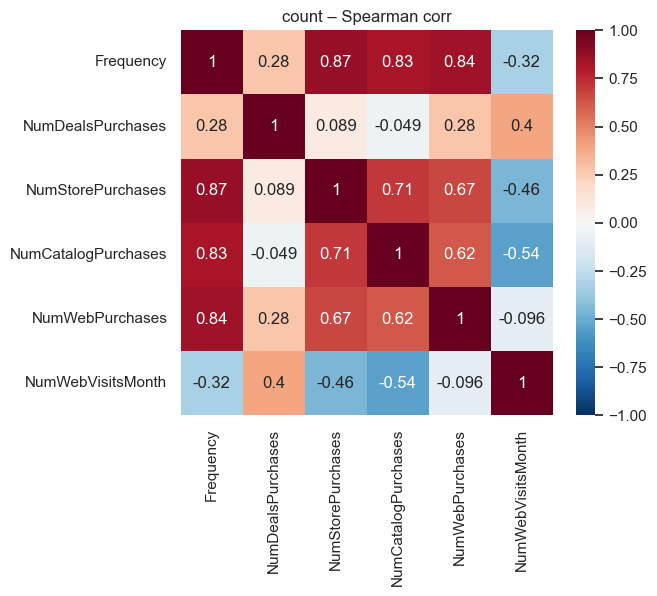


=== BASE_NUM (10 vars) ===


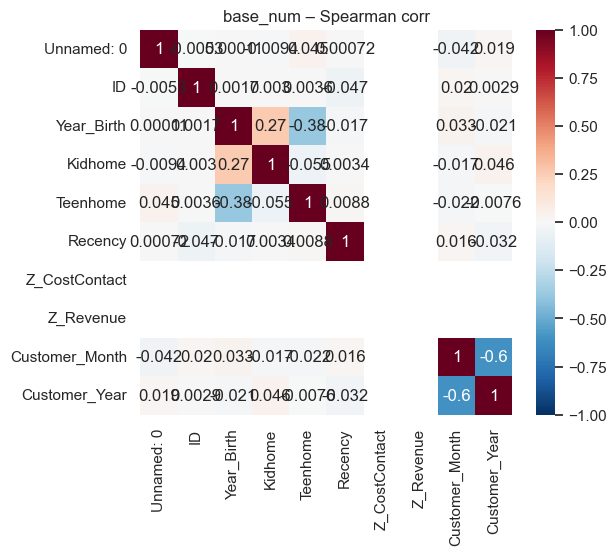


=== BOOL (6 vars) ===


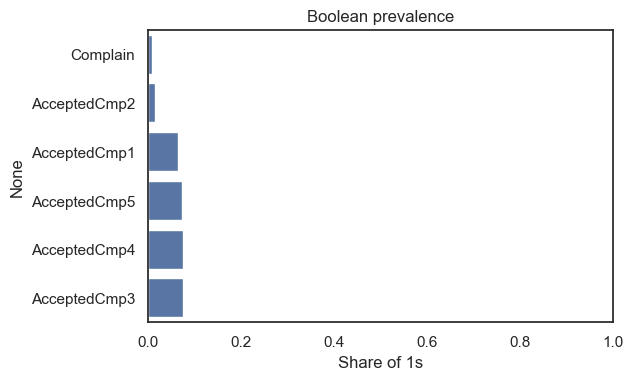


=== CAT (6 vars) ===


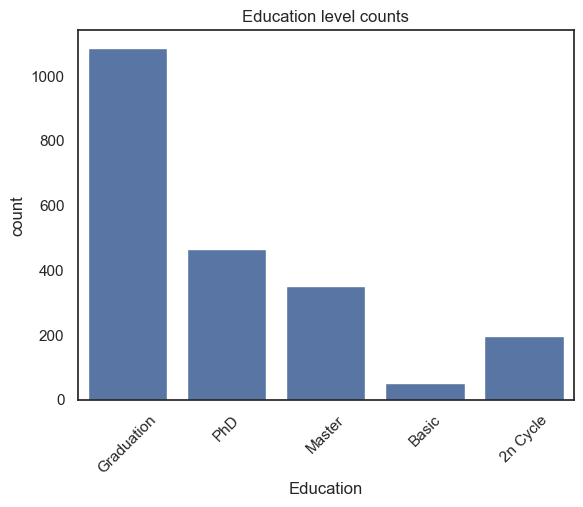

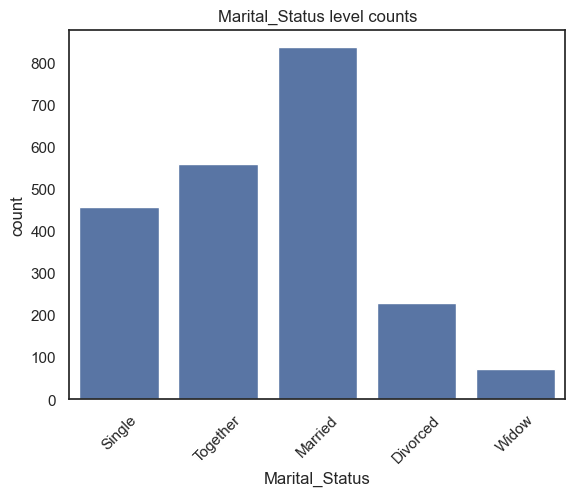

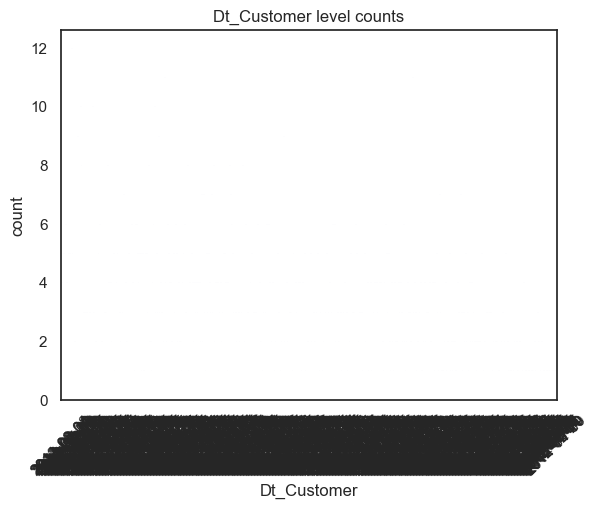

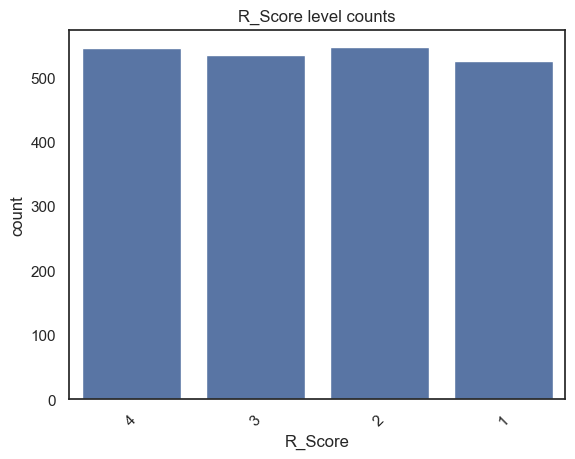

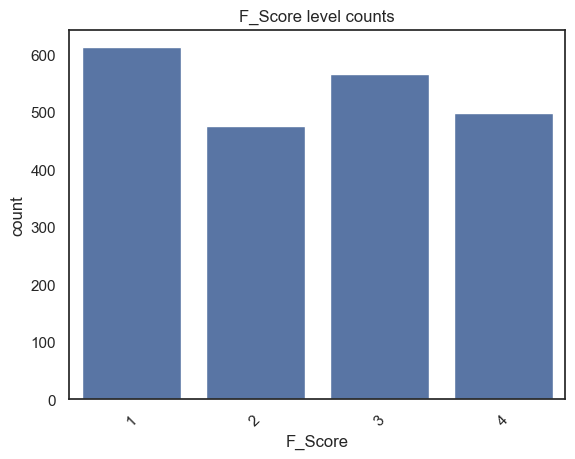

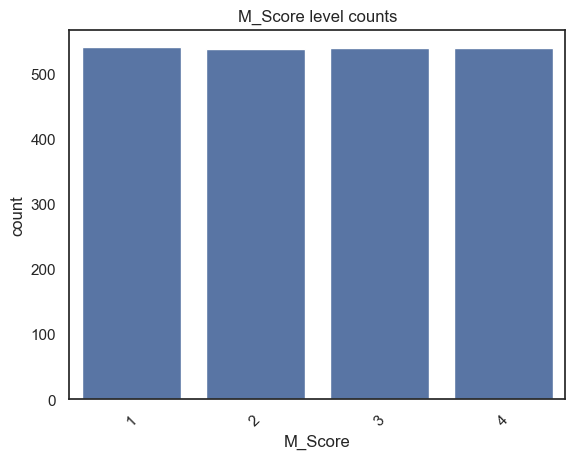

In [19]:
GROUPS = {
    "money" : money_cols,
    "count" : count_cols,
    "base_num" : num_cols,
    "bool"  : bool_cols,            # plot as bar of 0/1 prevalence
    "cat"   : cat_cols              # categorical counts
}

def quick_eda_groups(df, groups=GROUPS):
    for gname, cols in groups.items():
        if not cols:             # skip empty lists
            continue
        print(f"\n=== {gname.upper()} ({len(cols)} vars) ===")
        
        # --- Histograms / skew check -----------------------------------
        if gname in ("money", "count", "num"):
            for col in cols:
                fig, ax = plt.subplots(1, 2, figsize=(10, 3))
                sns.histplot(df[col], bins=50, ax=ax[0])
                ax[0].set_title(f"{col} raw")
                sns.histplot(np.log1p(df[col]), bins=50, ax=ax[1])
                ax[1].set_title(f"{col} log1p")
                plt.show()
        
        # --- Correlation heat-map for numeric groups -------------------
        if gname in ("money", "count", "base_num") and len(cols) > 1:
            plt.figure(figsize=(6,5))
            sns.heatmap(df[cols].corr('spearman'),
                        cmap='RdBu_r', vmin=-1, vmax=1, annot=True)
            plt.title(f"{gname} – Spearman corr"); plt.show()
        
        # --- Bool prevalence ------------------------------------------
        if gname == "bool":
            prevalence = df[cols].mean().sort_values()      # fraction of 1s
            plt.figure(figsize=(6, 0.3*len(prevalence)+2))
            sns.barplot(x=prevalence.values, y=prevalence.index, orient='h')
            plt.xlim(0, 1); plt.xlabel("Share of 1s"); plt.title("Boolean prevalence")
            plt.show()
        
        # --- Categorical level distribution ---------------------------
        if gname == "cat":
            for col in cols:
                sns.countplot(x=col, data=df)
                plt.title(f"{col} level counts"); plt.xticks(rotation=45)
                plt.show()

quick_eda_groups(df_model)


In [20]:
df_model['Monetary'].describe(percentiles=[.5, .9, .95, .99])


count    2.154000e+03
mean     1.268403e+04
std      5.072295e+05
min      5.000000e+00
50%      4.025000e+02
90%      1.542800e+03
95%      1.793050e+03
99%      2.174390e+03
max      2.342483e+07
Name: Monetary, dtype: float64

There is a massive outlier in Monetary, MntSweetProducts and others. This will need to be considered when building the pipelines and the model. A lot of the distributions are also skewed to the right. Before dealing with collinearity, we will run the model with outlier clipping and log/ sqrt normalization.


* drop columns not necessary for modeling


In [23]:
# find age using Year_Birth
df_model['Age'] = ((pd.to_datetime('today') -
                    pd.to_datetime(df_model['Year_Birth'], format='%Y')).dt.days // 365)
df_model = df_model.drop(columns=['Year_Birth'])


In [24]:
#drop all other columns that are irrelevant
df_model = df_model.drop(columns=['Customer_Month', 'Customer_Year'])


# 2. Modeling


* Prepare `X` and `y`


In [38]:
X = df_model.drop([    
    'Unnamed: 0', 
    'ID', 
    'Dt_Customer',
    'Response'
], 
    axis='columns'
) 

y = df_model['Response']


In [39]:
all_cols = X.columns                        # use the final columns only

money_cols = [c for c in money_cols  if c in all_cols]
count_cols = [c for c in count_cols  if c in all_cols]
num_cols   = [c for c in num_cols    if c in all_cols]
cat_cols   = [c for c in cat_cols    if c in all_cols]
bool_cols  = [c for c in bool_cols   if c in all_cols]


In [40]:
X.head()


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Frequency,Monetary,R_Score,F_Score,M_Score,Age
0,Graduation,Single,58138,0,0,58,635.0,88.0,546,172,88,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,25,1617.0,2,4,4,68
1,Graduation,Single,46344,1,1,38,11.0,1.0,6,2,1,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,6,27.0,3,1,1,71
2,Graduation,Together,71613,0,0,26,426.0,49.0,127,111,21,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,21,776.0,3,3,3,60
3,Graduation,Together,26646,1,0,26,11.0,4.0,20,10,3,5.0,2,2,0,4,6,0,0,0,0,0,0,3,11,8,53.0,3,1,1,41
4,PhD,Married,58293,1,0,94,173.0,43.0,118,46,27,15.0,5,5,3,6,5,0,0,0,0,0,0,3,11,19,422.0,1,3,3,44


In [41]:
y.head()


0     True
1    False
2    False
3    False
4    False
Name: Response, dtype: bool

* Train and test split - 20%


In [43]:
# hold-out split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,
    stratify=y,
    random_state=42
)


* Define our model pipeline


In [45]:
# helper transformers
# remove outliers by clipping the top to the 99th percentile
clip99 = FunctionTransformer(
    lambda x: np.minimum(x, np.quantile(x, 0.99, axis=0)), validate=False
)

# compress right-skewed distributions
safe_log1p = FunctionTransformer(
    lambda x: np.log1p(np.clip(x, a_min=0, a_max=None)),
    validate=False
)
sqrt = FunctionTransformer(np.sqrt, validate=False)

# define subpipelines to transform each column group
money_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clip', clip99),
    ('log', safe_log1p),
    ('scale', StandardScaler())
])

count_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clip', clip99),
    ('log', safe_log1p),
    ('scale', StandardScaler())
])

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('money', money_pipe, money_cols),
        ('count', count_pipe, count_cols),
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
        ('bool', 'passthrough', bool_cols)
    ],
    remainder='drop',        
    verbose_feature_names_out=False 
)


### Quick sanity checklist

- [ ] Every column appears **exactly once** in one of the lists.  
- [ ] Monetary & Income: clip-99 % → `log1p` → scale.  
- [ ] Count features: clip-99 % → `sqrt`/`log1p` → scale.  
- [ ] Baseline numerics: imput-median → scale.  
- [ ] Categoricals: impute-mode → one-hot.  
- [ ] Booleans: passthrough (already 0/1), or include in `count_pipe` if you want.  
- [ ] `remainder="drop"` so nothing “slips through.”


In [185]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# class 1 = responders (minority), class 0 = non-responders
classes   = np.unique(y_train)
weights   = compute_class_weight("balanced", classes=classes, y=y_train)
weight_map = {cls: w for cls, w in zip(classes, weights)}

row_weights = y_train.map(weight_map).values    # ndarray, same order as X_train


In [187]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [193]:
def objective(trial):
    
    # 1) PCA toggle + n_components
    use_pca = trial.suggest_categorical('use_pca', [True, False])
    if use_pca:
        n_comp = trial.suggest_int('pca__n_components', 5, min(len(num_cols), 30))
    
    n_hidden = trial.suggest_int("n_hidden_layers", 1, 3)
    hidden_sizes = [
        trial.suggest_int(f"layer{i}_units", 2, 100, step=2)
        for i in range(n_hidden)
    ]
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    solver     = trial.suggest_categorical("solver", ["adam", "sgd"])
    lr_init    = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    alpha      = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_int("batch_size", 32, 256, step=32)
    learn_rate = "adaptive" if solver == "sgd" else "constant"


    mlp = Pipeline([
        ("preproc", preprocessor),
        ("clf", MLPClassifier(
            hidden_layer_sizes = tuple(hidden_sizes),
            activation         = activation,
            solver             = solver,
            learning_rate      = learn_rate,
            learning_rate_init = lr_init,
            alpha              = alpha,
            batch_size         = batch_size,
            max_iter           = 300,
            early_stopping     = True,
            n_iter_no_change   = 15,
            random_state       = 42
        ))
    ])

    scoring = {"auc":"roc_auc", 
               "precision":"precision",
               "recall":"recall",
               "f1":"f1"}

    res = cross_validate(mlp, 
                         X_train, 
                         y_train,
                         cv=cv, 
                         scoring=scoring, 
                         n_jobs=-1)

    auc = res["test_auc"].mean()
    prec = res["test_precision"].mean()
    rec = res["test_recall"].mean()
    f1 = res["test_f1"].mean()

    # if rec < 0.50:
    #    raise optuna.exceptions.TrialPruned()

    return 0.4*auc + 0.2*prec + 0.2*rec + 0.2*f1


[I 2025-04-29 23:25:53,936] A new study created in memory with name: no-name-3fb04e82-a1ee-4e3a-bdec-f1664c2f8fcb


  0%|          | 0/500 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:25:55,573] Trial 0 finished with value: 0.5429392117830567 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 1, 'layer0_units': 58, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.007574263144790174, 'alpha': 0.003951312847598276, 'batch_size': 224}. Best is trial 0 with value: 0.5429392117830567.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:25:56,349] Trial 1 finished with value: 0.17947352027624186 and parameters: {'use_pca': False, 'n_hidden_layers': 3, 'layer0_units': 24, 'layer1_units': 76, 'layer2_units': 8, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.0003998569197966447, 'alpha': 0.00225082179894641, 'batch_size': 96}. Best is trial 0 with value: 0.5429392117830567.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:25:56,843] Trial 2 finished with value: 0.3491256531652341 and parameters: {'use_pca': False, 'n_hidden_layers': 1, 'layer0_units': 46, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.0016940038054979324, 'alpha': 0.0005998845853972052, 'batch_size': 256}. Best is trial 0 with value: 0.5429392117830567.
[I 2025-04-29 23:25:57,427] Trial 3 finished with value: 0.7027566129278827 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 86, 'layer1_units': 76, 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0022075676834167036, 'alpha': 0.001020664321320915, 'batch_size': 160}. Best is trial 3 with value: 0.7027566129278827.
[I 2025-04-29 23:26:01,388] Trial 4 finished with value: 0.6901427516270875 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 3, 'layer0_units': 86, 'layer1_units': 74, 'layer2_units': 80, 'activation': 'tanh', 'solver': 'sgd', 'learning_rate_init': 0.0085

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:26:20,700] Trial 26 finished with value: 0.2682209851914462 and parameters: {'use_pca': False, 'n_hidden_layers': 2, 'layer0_units': 54, 'layer1_units': 12, 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.00010604572482425019, 'alpha': 0.0019764722792588243, 'batch_size': 64}. Best is trial 3 with value: 0.7027566129278827.
[I 2025-04-29 23:26:21,088] Trial 27 finished with value: 0.6758080512865013 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 34, 'layer1_units': 18, 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0006317906587835143, 'alpha': 0.004375320296158059, 'batch_size': 96}. Best is trial 3 with value: 0.7027566129278827.
[I 2025-04-29 23:26:21,365] Trial 28 finished with value: 0.6301746046766512 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 1, 'layer0_units': 2, 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0013806071906910973, 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:26:27,228] Trial 40 finished with value: 0.1662399273896938 and parameters: {'use_pca': False, 'n_hidden_layers': 2, 'layer0_units': 36, 'layer1_units': 92, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.0005002436240133072, 'alpha': 0.00019341120958469554, 'batch_size': 96}. Best is trial 35 with value: 0.7046484615851094.
[I 2025-04-29 23:26:27,878] Trial 41 finished with value: 0.6743965752020912 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 66, 'layer1_units': 80, 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.0021743700284602646, 'alpha': 0.00601468172380044, 'batch_size': 64}. Best is trial 35 with value: 0.7046484615851094.
[I 2025-04-29 23:26:28,806] Trial 42 finished with value: 0.7058460266528868 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 74, 'layer1_units': 70, 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:27:57,452] Trial 146 finished with value: 0.5800084746339449 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 48, 'layer1_units': 48, 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.0014601126375628484, 'alpha': 0.000845175680228938, 'batch_size': 64}. Best is trial 130 with value: 0.733131745511369.
[I 2025-04-29 23:27:57,956] Trial 147 finished with value: 0.707632261474762 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 76, 'layer1_units': 76, 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.008443756671345603, 'alpha': 0.0029681979616236276, 'batch_size': 64}. Best is trial 130 with value: 0.733131745511369.
[I 2025-04-29 23:27:58,569] Trial 148 finished with value: 0.7076309654027017 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 76, 'layer1_units': 76, 'activation': 'tanh', 'solver': 'adam',

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-29 23:30:45,964] Trial 488 finished with value: 0.49170970508246264 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 66, 'layer1_units': 34, 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.00018299617110514445, 'alpha': 8.538998879619723e-05, 'batch_size': 128}. Best is trial 130 with value: 0.733131745511369.
[I 2025-04-29 23:30:46,351] Trial 489 finished with value: 0.6866001290098853 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 3, 'layer0_units': 70, 'layer1_units': 28, 'layer2_units': 48, 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.005778417301128424, 'alpha': 0.00012052340191858518, 'batch_size': 192}. Best is trial 130 with value: 0.733131745511369.
[I 2025-04-29 23:30:46,696] Trial 490 finished with value: 0.7162095979365664 and parameters: {'use_pca': True, 'pca__n_components': 5, 'n_hidden_layers': 2, 'layer0_units': 74, 'layer1_units': 30, 'activation'

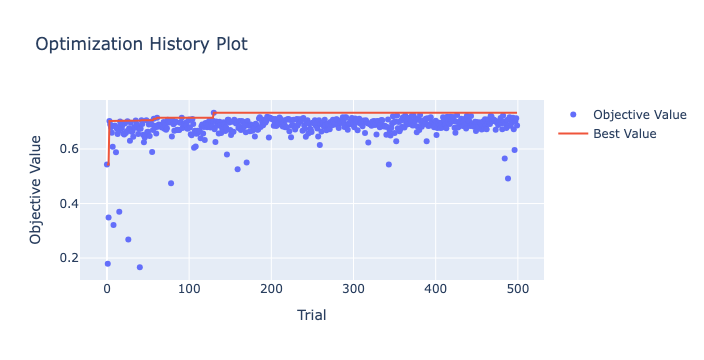

In [195]:
study = optuna.create_study(direction='maximize')  
study.optimize(objective, n_trials=500, show_progress_bar=True)

# After completion, get the best hyperparameters and score
print("Best Score:", study.best_value)
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

optuna.visualization.plot_optimization_history(study)


In [197]:
bad_cols = []
for col in money_cols + count_cols:
    if (X_train[col] <= -1).any():
        bad_cols.append(col)
print("Cols with values <= -1:", bad_cols)
print(X_train[bad_cols].min())


Cols with values <= -1: ['MntFishProducts']
MntFishProducts   -1
dtype: int64


In [199]:
all_cols = set(X_train.columns)

def check(group, names):
    missing = [c for c in names if c not in all_cols]
    if missing:
        print(f"{group}: {missing}")

check("money_cols", money_cols)
check("count_cols", count_cols)
check("base_num",   num_cols)
check("cat_cols",   cat_cols)
check("bool_cols",  bool_cols)


In [201]:
best_params = study.best_params


In [203]:
params = deepcopy(best_params)
n_hidden = params.pop("n_hidden_layers")
hidden_sizes = tuple(
    params.pop(f"layer{i}_units") for i in range(n_hidden)
)


In [205]:
clf_kwargs = dict(
    hidden_layer_sizes = hidden_sizes,
    activation         = params["activation"],
    solver             = params["solver"],
    learning_rate      = "adaptive" if params["solver"] == "sgd" else "constant",
    learning_rate_init = params["learning_rate_init"],
    alpha              = params["alpha"],
    batch_size         = params["batch_size"],
    max_iter           = 300,            # keep the constants you used
    early_stopping     = True,
    n_iter_no_change   = 15,
)


In [207]:
# 2. Rebuild the pipeline with those params
best_mlp = Pipeline([
    ("preproc", preprocessor),                 # your ColumnTransformer
    ("clf", MLPClassifier(
        **clf_kwargs,                         # unpack n_estimators, max_depth, …
        random_state=42
    ))
])

# 3. Fit once on the whole training data
best_mlp.fit(X_train, y_train)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('money',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clip',
                                                                   FunctionTransformer(func=<function <lambda> at 0x169209580>)),
                                                                  ('log',
                                                                   FunctionTransformer(func=<function <lambda> at 0x1692094e0>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Monetary', 'Income',
                                                   'MntWines', 'MntFruits',
                                                   'MntMeatProducts...
                                                   'AcceptedCmp3',
                                                   'AcceptedCmp4',
                                                   'AcceptedCmp5',
                                                   'Complain'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 MLPClassifier(activation='tanh', alpha=0.003941490803175976,
                               batch_size=32, early_stopping=True,
                               hidden_layer_sizes=(58, 50),
                               learning_rate='adaptive',
                               learning_rate_init=0.006317262558664671,
                               max_iter=300, n_iter_no_change=15,
                               random_state=42, solver='sgd'))])

* **Precision:** TP / (TP + FP) --> the amount of true positives for all the predicted positives; high precision means few negatives labeled as positives (focus on the quality of positive predictions)
* **Recall:** TP / (TP + FN) --> the amount of true positives for all the actual positives in the data, including the ones falsely labeled as negatives. High recall means few positives labeled as negatives.


In [210]:
preds = best_mlp.predict(X_test)
proba = best_mlp.predict_proba(X_test)[:, 1]


# 3. Evaluation


In [213]:

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    preds,
    average=None                # one pair per class; use 'binary' or 'macro' if you want a single average
)

# 4. Round and print
print("Class 0 — Precision: {:.3f}, Recall: {:.3f}, F1: {:.3f}, Support: {}".format(
    precision[0], recall[0], f1[0], support[0]
))
print("Class 1 — Precision: {:.3f}, Recall: {:.3f}, F1: {:.3f}, Support: {}".format(
    precision[1], recall[1], f1[1], support[1]
))


Class 0 — Precision: 0.910, Recall: 0.973, F1: 0.941, Support: 366
Class 1 — Precision: 0.750, Recall: 0.462, F1: 0.571, Support: 65


In [215]:
print(classification_report(y_test, preds, digits=3))


              precision    recall  f1-score   support

       False      0.910     0.973     0.941       366
        True      0.750     0.462     0.571        65

    accuracy                          0.896       431
   macro avg      0.830     0.717     0.756       431
weighted avg      0.886     0.896     0.885       431



In [217]:
print(classification_report(y_test, proba >= 0.7, digits=3))


              precision    recall  f1-score   support

       False      0.880     0.984     0.929       366
        True      0.727     0.246     0.368        65

    accuracy                          0.872       431
   macro avg      0.804     0.615     0.648       431
weighted avg      0.857     0.872     0.844       431



In [240]:
print(classification_report(y_test, proba >= 0.26, digits=3))


              precision    recall  f1-score   support

       False      0.949     0.918     0.933       366
        True      0.610     0.723     0.662        65

    accuracy                          0.889       431
   macro avg      0.780     0.821     0.798       431
weighted avg      0.898     0.889     0.892       431



* Creating a `results` dataframe to hold our probabilities of being positive, our prediction and the ground truth reality


In [243]:
results = pd.DataFrame()

results['proba_true'] = proba
results['prediction'] = preds
results['ground_truth'] = y_test.values

results.head()


,proba_true,prediction,ground_truth
0,0.016948,False,False
1,0.098870,False,False
2,0.617953,True,False
3,0.164902,False,False
4,0.011577,False,False


In [265]:
results.isna().value_counts()


proba_true  prediction  ground_truth
False       False       False           431
Name: count, dtype: int64

* Probability of a sample being POSITIVE (X = 1) for X = 0 and X = 1 separately


In [246]:
(
    results.loc[
        results.ground_truth == 0
    ].hvplot.hist(
        y='proba_true', 
        bin_range=(0,1), 
        bins=20,
        color='green',
        alpha=0.3,
        legend='bottom',
        label='REAL 0',
        height=200,
        title='P(X = 1) for Samples that are X = 0'
    ) + \
    results.loc[
        results.ground_truth == 1
    ].hvplot.hist(
        y='proba_true', 
        bin_range=(0,1), 
        bins=20,
        color='red',
        alpha=0.3,
        label='REAL 1',
        height=200,
        title='P(X = 1) for Samples that are X = 1'
    )
).cols(1).opts(shared_axes=False)


:Layout
   .Histogram.I  :Histogram   [proba_true]   (proba_true_count)
   .Histogram.II :Histogram   [proba_true]   (proba_true_count)

* Confusion Matrix of our Test Set


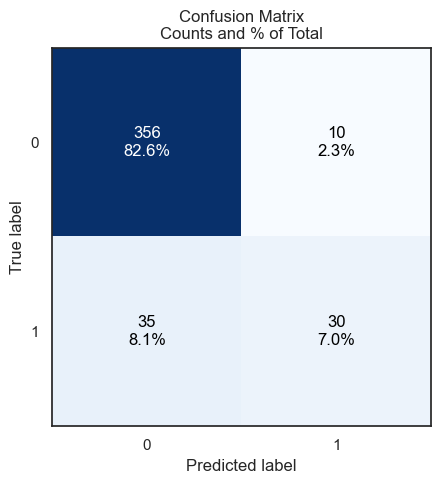

In [249]:
# 1) Compute the matrix
cm = confusion_matrix(y_test, preds)
cm_pct = cm / cm.sum()  # overall percentage

# 2) Create the display WITHOUT internal annotations
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(
    ax=ax,
    include_values=False,   # <— disable the default counts
    colorbar=False,
    cmap="Blues"
)

# 3) Add your own count+percent, with dynamic text color for readability
nrows, ncols = cm.shape
for i in range(nrows):
    for j in range(ncols):
        count = cm[i, j]
        pct   = cm_pct[i, j] * 100
        # pick white text on dark cells, black on light cells
        bg = cm_pct[i, j]
        text_color = "white" if bg > 0.5 else "black"
        ax.text(
            j, i,
            f"{count}\n{pct:.1f}%",
            ha="center", va="center",
            fontsize=12,
            color=text_color
        )

ax.set_title("Confusion Matrix\nCounts and % of Total")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


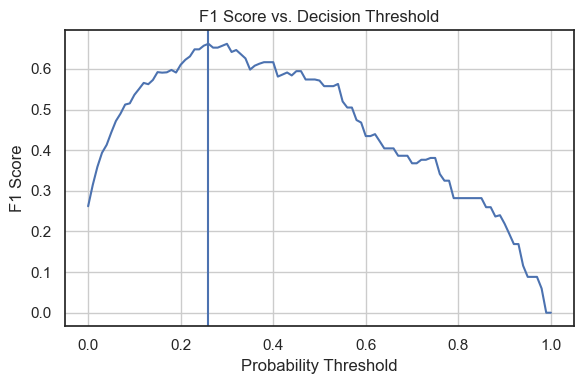

Best threshold: 0.260  →  F1 = 0.662


In [228]:
# 1) Get true labels and predicted probabilities on your hold-out set
y_true = y_test
# already computed up there
# proba   = basic_pipe.predict_proba(X_test)[:, 1]

# 3) Sweep thresholds and compute F1
thresholds = np.linspace(0, 1, 101)
f1_scores  = [f1_score(y_true, proba >= t) for t in thresholds]

# 4) Find the best threshold
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

# 5) Plot F1 vs. threshold and mark best
plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold)                # vertical line at best threshold
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6) Report the best threshold
print(f"Best threshold: {best_threshold:.3f}  →  F1 = {best_f1:.3f}")


▶ Optimal threshold = 0.26 → Profit €286.0
  Precision @ 0.26 = 61.04%
  Recall    @ 0.26 = 72.31%


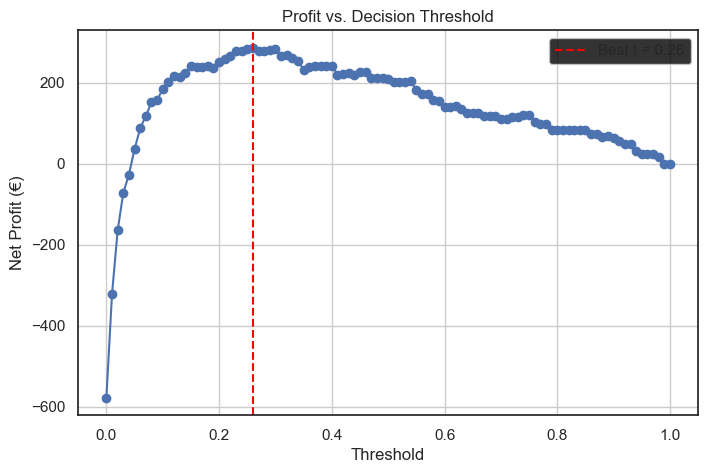

In [230]:
# 1. Build a grid of thresholds
thresholds = np.linspace(0.0, 1.0, 101)

# 2. For each threshold, compute TP, FP, precision, recall, and profit
records = []
for t in thresholds:
    # apply threshold
    preds_t = (proba >= t).astype(int)

    # confusion matrix: tn, fp, fn, tp
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()

    # compute precision/recall if you want
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # compute profit: +8€ per TP, –3€ per FP
    profit_t = 8 * tp - 3 * fp

    records.append({
        'threshold':    t,
        'TP':           tp,
        'FP':           fp,
        'precision':    precision_t,
        'recall':       recall_t,
        'profit':       profit_t
    })

df_thresh = pd.DataFrame(records)

# 3. Find your optimal threshold
best_idx      = df_thresh['profit'].idxmax()
best_row      = df_thresh.loc[best_idx]
best_thr      = best_row['threshold']
best_profit   = best_row['profit']
best_precision= best_row['precision']
best_recall   = best_row['recall']

print(f"▶ Optimal threshold = {best_thr:.2f} → Profit €{best_profit}")
print(f"  Precision @ {best_thr:.2f} = {best_precision:.2%}")
print(f"  Recall    @ {best_thr:.2f} = {best_recall:.2%}")

# 4. Plot Profit vs Threshold
plt.figure(figsize=(8,5))
plt.plot(df_thresh['threshold'], df_thresh['profit'], marker='o', linestyle='-')
plt.axvline(best_thr, color='red', linestyle='--',
            label=f"Best t = {best_thr:.2f}")
plt.xlabel('Threshold')
plt.ylabel('Net Profit (€)')
plt.title('Profit vs. Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()


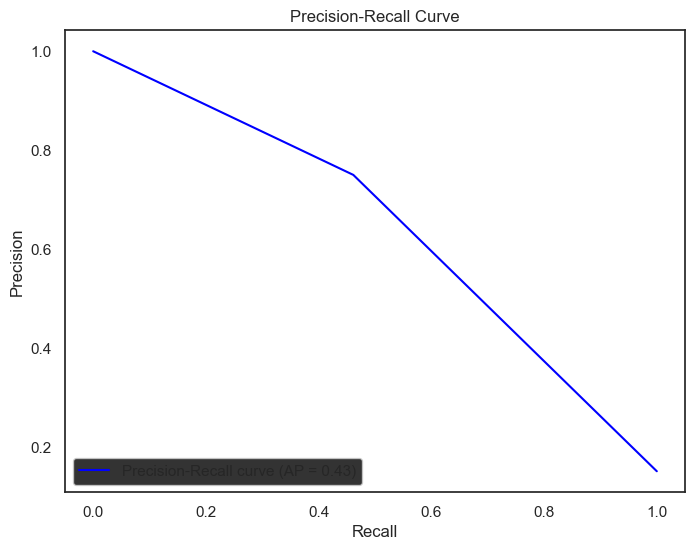

In [232]:

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, preds)
avg_precision = average_precision_score(y_test, preds)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()
